In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import genextreme

In [20]:
import xarray as xr
import glob

# Find all ERA5 NetCDF files
files = sorted(glob.glob(r"C:\Users\jerji\PyCharmMiscProject\Data\ERA5\*.nc"))

print(f"Found {len(files)} files")

# Load ALL files together
ds = xr.open_mfdataset(files, combine='by_coords')

# Avoid buggy print(ds)
print(list(ds.data_vars))

# Check dimensions
print(ds.dims)

Found 36 files
['u10', 'v10']
FrozenMappingWarningOnValuesAccess({'valid_time': 315576, 'latitude': 13, 'longitude': 29})


In [41]:
wind_speed = np.sqrt(ds['u10']**2 + ds['v10']**2)
alpha = 0.11
z_target = 100
z_ref = 10

wind_speed_100m = wind_speed * (z_target / z_ref) ** alpha
print(wind_speed.shape)

(315576, 13, 29)


In [22]:
print(list(ds.data_vars))

['u10', 'v10']


In [57]:
wind_dom_max = wind_speed_100m.max(dim=['latitude', 'longitude'])

print(wind_dom_max.shape)


(315576,)


In [65]:
annual_max = wind_dom_max.groupby('valid_time.year').max()

print(annual_max.shape)


(36,)


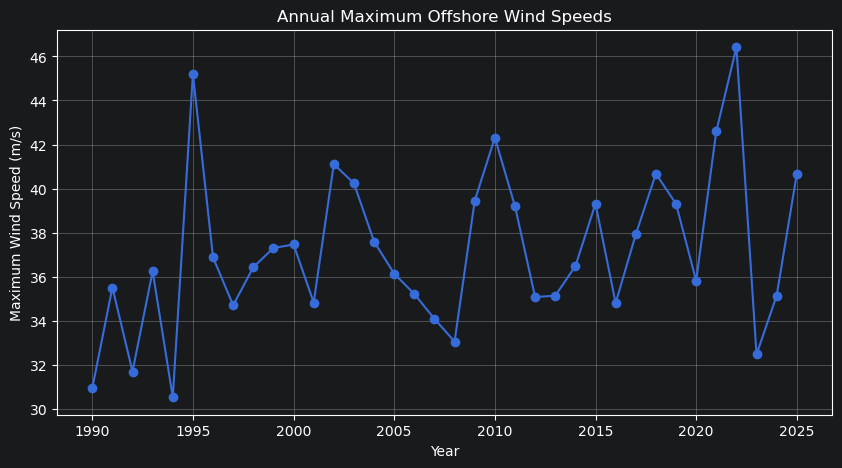

In [66]:
plt.figure(figsize=(10,5))

plt.plot(
    annual_max['year'],
    annual_max.values,
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Maximum Wind Speed (m/s)')
plt.title('Annual Maximum Offshore Wind Speeds')
plt.grid(True)

plt.show()

In [67]:
maxima = annual_max.values

shape, loc, scale = genextreme.fit(maxima)

print("GEV Parameters:")
print("Shape =", shape)
print("Location =", loc)
print("Scale =", scale)

GEV Parameters:
Shape = 0.14080778524225285
Location = 35.66349427008727
Scale = 3.284594157910359


In [68]:
return_periods = np.array([10, 50, 100])

# Exceedance probabilities
probabilities = 1 - 1 / return_periods

return_levels = genextreme.ppf(
    probabilities,
    shape,
    loc=loc,
    scale=scale
)

print("\nReturn Levels:")

for rp, rl in zip(return_periods, return_levels):
    print(f"{rp}-year return level: {rl:.2f} m/s")




Return Levels:
10-year return level: 42.00 m/s
50-year return level: 45.52 m/s
100-year return level: 46.79 m/s


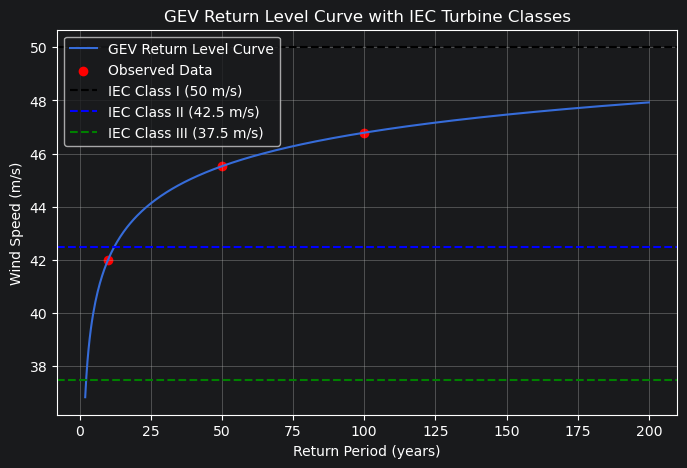

In [69]:
rp_range = np.linspace(2, 200, 500)

prob = 1 - 1 / rp_range

rl_curve = genextreme.ppf(
    prob,
    shape,
    loc=loc,
    scale=scale
)

plt.figure(figsize=(8,5))

plt.plot(rp_range, rl_curve, label='GEV Return Level Curve')
plt.scatter(return_periods, return_levels, color='red', label='Observed Data')

# IEC turbine class thresholds
plt.axhline(50, linestyle='--', color='black', label='IEC Class I (50 m/s)')
plt.axhline(42.5, linestyle='--', color='blue', label='IEC Class II (42.5 m/s)')
plt.axhline(37.5, linestyle='--', color='green', label='IEC Class III (37.5 m/s)')

plt.xlabel('Return Period (years)')
plt.ylabel('Wind Speed (m/s)')
plt.title('GEV Return Level Curve with IEC Turbine Classes')

plt.grid(True)
plt.legend()

plt.show()


In [63]:
x = np.sort(annual_max.values); n = len(x); emp = np.arange(1, n+1)/(n+1); gev = genextreme.cdf(x, shape, loc=loc, scale=scale); print("Mean % error:", np.mean(100*np.abs(emp-gev)/emp), "Max % error:", np.max(100*np.abs(emp-gev)/emp))

Mean % error: 12.784875343623227 Max % error: 43.15348795634914
